### What Is LangGraph

Powerful framework designed to help developers to build intelligent AI agents that can think, plan, and act on our behalf. It allows us to breakdown complex task into smaller, manageable steps, organize these steps logicallyc, and connect them like a roadmap using somethig called <b>graphs</b>.<br>
These LangGraph don't just follow instructions, they understand what you want, figure out the best was to achieve it and carry out the task automatically.


## Why LangGraph


1. <B>Support for Cyclic graph:</b><Br>
    E.g An Ai agent analyzing customer feedback might revisit earlier steps to refine its understanding based on new data<br>
2. <b>Enhanced Workflow Flexibility</b><br>
    As these are cyclic graph it make langgraph ideal for real-world scenarios where tasks don't always follow a one path. It can handle dynamic workflows where agents need to adapt, reevauate, or repeat steps as needed, providing greater flexibility.<br>
3. <b>Powerful Iteractive Processes</b><br>
    By enabling loops, LangGraph supports processes such as optimization, data refinement, or real-time adjustments, ensuring the AI agent delivers more accurate and meaningful results.<Br>
4. <b>ALL In One Solution</b><br>
    LangGraph doesn’t just manage tasks but also integrates the benefits of both DAGs (for structured flows) and cyclic graphs (for iterative workflows). This makes it a more versatile framework for designing intelligent, adaptable AI agents.
    

<b>Required Library for Langraph

In [51]:
# pip install langgraph
from langgraph.graph import StateGraph

In [52]:
# Set the llm
import os
from dotenv import load_dotenv
load_dotenv()
from langchain_google_genai import ChatGoogleGenerativeAI
llm = ChatGoogleGenerativeAI(api_key = os.getenv("GOOGLE_API_KEY"), model = "gemini-2.5-flash")


## Components Of Langgraph


Lets first discuss components of langgraph
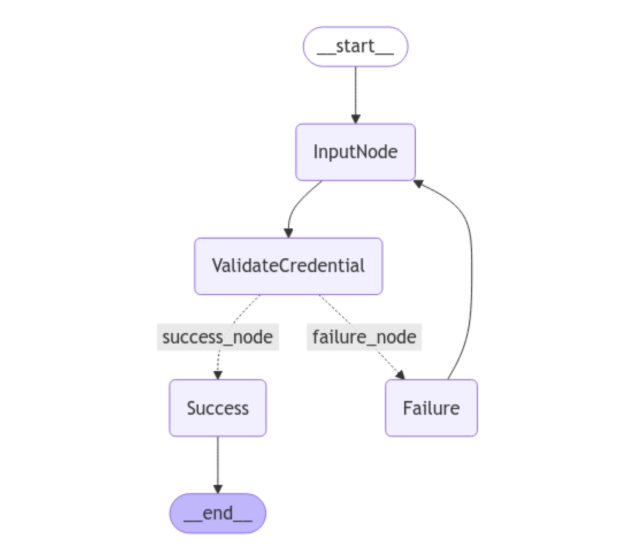

1. <b>States</b><br>
States represent the current condition or context within the workflow. They score and manage information as the agent progresses from one node to the next<br>
Eg: A state might capture user input, store the results of a database query, or reflect the status of an ongoing process.<br>

<B>States Keys And Types:</b><br>
<li>
username: Optional[str] - The user's username; it can be a string or None.<br>
<li>password: Optional[str] - The user's password; it can be a string or None.<br>
<li>is_authenticated: Optional[bool] - Indicates whether the user is authenticated; it can be a boolean or None.<br>
<li>output: Optional[str] - A message or result related to authentication; it can be a string or None.

In [53]:
# How we define state 
from typing import TypedDict, Optional
class AuthState(TypedDict):
    username: Optional[str]
    password: Optional[str]
    is_authenticated: Optional[bool]
    output: Optional[str]

<b>Example Objects and Their States

In [54]:
auth_state_1: AuthState = {
    "username": "alice123",
    "password": "123",
    "is_authenticated": True,
    "output": "Login successful."
}
print(f"auth_state_1: {auth_state_1}")

auth_state_1: {'username': 'alice123', 'password': '123', 'is_authenticated': True, 'output': 'Login successful.'}


In [55]:
auth_state_2: AuthState = {
    "username":"",
    "password": "wrongpassword",
    "is_authenticated": False,
    "output": "Authentication failed. Please try again."
}
print(f"auth_state_2: {auth_state_2}")

auth_state_2: {'username': '', 'password': 'wrongpassword', 'is_authenticated': False, 'output': 'Authentication failed. Please try again.'}


2. <b>Nodes

Nodes are the core units of action in LangGraph. Each node represents a specific task or operation that the AI agent need to perform<br>
For Example: A node could fetch data from an API, process information, or generate a response

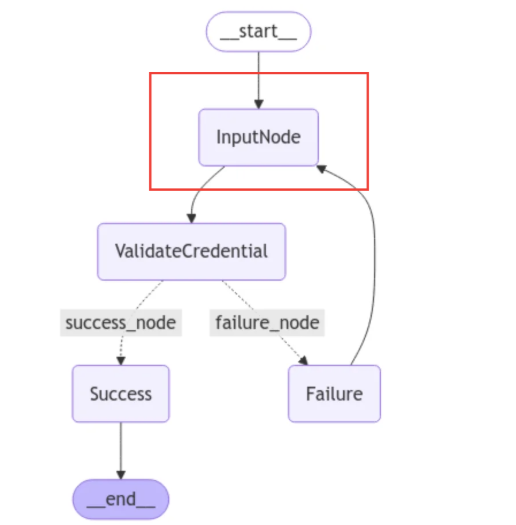

In the above picture InputNode, ValidateCredential, Sucess, Failure and the __end__ are the nodes. Lets define each node


In [56]:
# InputNode
def input_node(state):
    print(state)
    if state.get("username","") == "":
        username = input("What is your username")

    password = input("What is your Password?")
    if state.get("username", "") == "":
        return {"username": username, "password":password}
    else:
        return {"password": password}

We pass in the first object with all the fields, and input_node prompts us for the password

<b>Validate Credential Node

In [57]:
def validate_credentials_node(state):
    # Extract username and password from the state
    username = state.get("username","")
    password = state.get("password","")

    print("Username: ",username, "Password: ",password)

    # Simulate credential location
    if username == "test_user" and password == "secure_password":
        is_authenticated = True
    else:
        is_authenticated = False
    
    return {"is_authenticated": is_authenticated}



<b> Success Node


In [58]:
def success_node(state):
    return {"output":"Authenticated successful! Welcome"}

<b> Failure Node

In [59]:
def failure_node(state):
    return {"output":"not Successfull, please try again"}

<B>Router Node</b><br>
The router node is the decision-making point in the workflow. It takes the current state as input and determines the next node to execute based on the is_authneticated value in the state.

In [60]:
def router(state):
    if state['is_authenticated']:
        return "success_node"
    else:
        return "failure_node"

### Creating The Graph

In [61]:
from langgraph.graph import StateGraph
from langgraph.graph import END

# Create an instance of StateGraph with the GraphState structure
workflow = StateGraph(AuthState)
workflow

<b>Adding Nodes to the graph

Now we will add the nodes  to the graph to define the tasks of the workflow. Nodes are added using the add_node method

To gather user input for authentication, we add the input_node to the graph using the add_node method. This node prompts the user to enter their username and password if they are not already present in the state.

"InputNode": This is the unique identifier for the input node.<br>
input_node: The function that collects the username and password from the user and updates the state accordingly.

In [62]:
workflow.add_node("InputNode", input_node)

To handle the authentication logic, we add the validate_credentials_node to the graph using the add_node method. This node validates the username and password provided by the user and updates the state with the authentication result.

In [63]:
workflow.add_node("ValidateCredential", validate_credentials_node)

Now, we add the success_node to the graph using the add_node method. This node will be triggered if the credentials are validated successfully, and it will return a success message.

In [64]:
workflow.add_node("Sucess", success_node)

Next, we add the failure_node to the graph using the add_node method. This node will be triggered if the credentials are invalid, returning a failure message.

In [65]:
workflow.add_node("Failure", failure_node)

3. <b>Edges

Edges are the connections between the nodes and represent the flow of execution within the graph

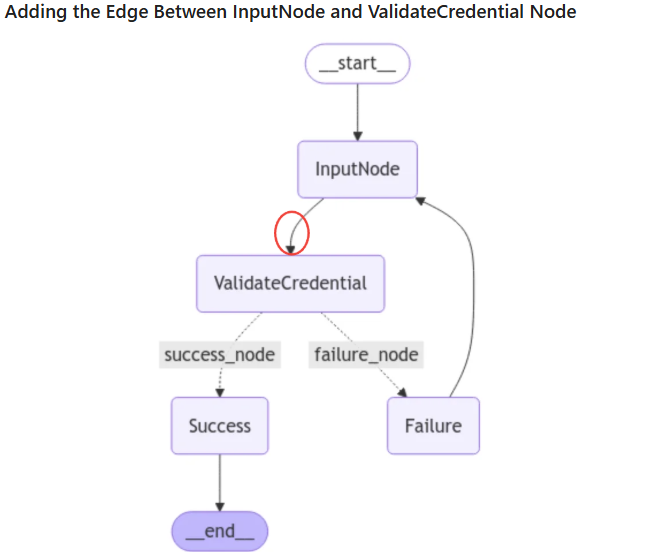

In [66]:
# add_edge method is used to connect the nodes
workflow.add_edge("InputNode", "ValidateCredential")

Similarly adding or edges in the following code

In [67]:
# Adding the edge between failure and input node
workflow.add_edge("Failure","InputNode")

4. <b>Credential Edges

Conditional edges enable decision-making by allowing transitions between nodes based on specific conditions within the state. These edges define the flow of execution based on outcomes such as user input, validation results, or any other predefined logic. By using conditional edges, the AI agent can dynamically choose its path based on the results of previous tasks.



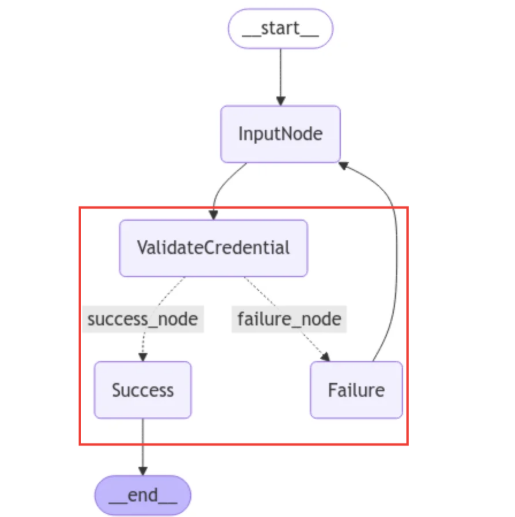

In [68]:
# add_conditional_edges defines the conditional transitions
workflow.add_conditional_edges("ValidateCredential", router, {"success_node":"Sucess", "failure_node":"Failure"})

start: The node where the conditional edges start (in this case, "ValidateCredential").<br>
router: A function that determines the condition. It checks the current state (like the is_authenticated status) and returns the appropriate node to transition to (either "Success" or "Failure").<Br>
conditions: A dictionary that maps conditions (such as "success_node" or "failure_node") to target nodes, indicating where to direct the flow based on the condition.

<b>Setting the Entry point

It is the point where the workflow starts

In [69]:
workflow.set_entry_point("InputNode")

<b>Compiling the workflow

Once everything is define in the workflow, the next step is to compile them. It transform the defined nodes, edges and logic into a ready-to-use application that can execute the defined task sequentially or conditionally

In [70]:
app = workflow.compile()

<b>Run the Application

Please note that the correct password is secure_password

In [71]:
inputs = {"username": "test_user"}
result = app.invoke(inputs)
print(result)

{'username': 'test_user'}
Username:  test_user Password:  secure_password
{'username': 'test_user', 'password': 'secure_password', 'is_authenticated': True, 'output': 'Authenticated successful! Welcome'}


In [72]:
result['output']

'Authenticated successful! Welcome'

## Building a Simple QA Workflow 

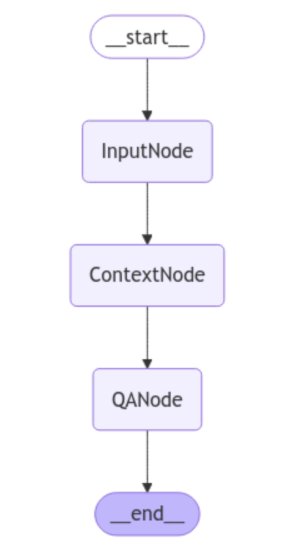

In [73]:
# Define the structure of the QA state
class QAState(TypedDict):
    # 'question' stores the user's input question. It can be a string or None if not provided.
    question: Optional[str]
    
    # 'context' stores relevant context about the guided project, if the question pertains to it.
    # If the question isn't related to the project, this will be None.
    context: Optional[str]
    
    # 'answer' stores the generated response or answer. It can be None until the answer is generated.
    answer: Optional[str]



In [74]:
qa_state_example = QAState(
    question="What is the purpose of this guided project?",
    context="This project focuses on building a chatbot using Python.",
    answer=None
)

# Print the attributes
for key, value in qa_state_example.items():
    print(f"{key}: {value}")

question: What is the purpose of this guided project?
context: This project focuses on building a chatbot using Python.
answer: None


In [75]:
def input_validation_node(state):
    # Extract the question from the state, and strip any leading or trailing spaces
    question = state.get("question", "").strip()
    
    # If the question is empty, return an error message indicating invalid input
    if not question:
        return {"valid": False, "error": "Question cannot be empty."}
    
    # If the question is valid, return valid status
    return {"valid": True}

In [76]:
def context_provider_node(state):
    question = state.get("question", "").lower()
    # Check if the question is related to the guided project
    if "langgraph" in question or "guided project" in question:
        context = (
            "This guided project is about using LangGraph, a Python library to design state-based workflows. "
            "LangGraph simplifies building complex applications by connecting modular nodes with conditional edges."
        )
        return {"context": context}
    # If unrelated, set context to null
    return {"context": None}

In [77]:
def llm_qa_node(state):
    # Extract the question and context from the state
    question = state.get("question", "")
    context = state.get("context", None)

    # Check for missing context and return a fallback response
    if not context:
        return {"answer": "I don't have enough context to answer your question."}

    # Construct the prompt dynamically
    prompt = f"Context: {context}\nQuestion: {question}\nAnswer the question based on the provided context."

    # Use LangChain's ChatOpenAI to get the response
    try:
        response = llm.invoke(prompt)
        return {"answer": response.content.strip()}
    except Exception as e:
        return {"answer": f"An error occurred: {str(e)}"}

In [78]:
qa_workflow = StateGraph(QAState)

In [79]:
qa_workflow.add_node("InputNode", input_validation_node)
qa_workflow.add_node("ContextNode", context_provider_node)
qa_workflow.add_node("QANode", llm_qa_node)

In [80]:
qa_workflow.set_entry_point("InputNode")

In [81]:
qa_workflow.add_edge("InputNode", "ContextNode")
qa_workflow.add_edge("ContextNode", "QANode")
qa_workflow.add_edge("QANode", END)

In [82]:
qa_app = qa_workflow.compile()

<b>Testing

In [83]:
# Asking the irrelevant question
qa_app.invoke({"question": "What is the weather today?"})

{'question': 'What is the weather today?',
 'context': None,
 'answer': "I don't have enough context to answer your question."}

In [84]:
qa_app.invoke({"question": "What is LangGraph?"})

{'question': 'What is LangGraph?',
 'context': 'This guided project is about using LangGraph, a Python library to design state-based workflows. LangGraph simplifies building complex applications by connecting modular nodes with conditional edges.',
 'answer': 'LangGraph is a Python library used to design state-based workflows. It simplifies building complex applications by connecting modular nodes with conditional edges.'}